# Proba 62 - Housing Dataset

#### Implementa usando PyTorch  e seguindo a documentación un clasificador para o dataset Housing. 

---

#### Instalación de recursos:

- `uv add ipykernel`

- `uv add jupyter`

- `uv add pandas`

- `uv add torch torchvision`

- `uv add matplotlib`

- `uv run ipython kernel install --user --name=proba72`

#### Usamos como kernel **proba72-HousingDataset**

---

#### Importamos librerías necesarias

In [179]:
import pandas as pd # type: ignore
from torch.utils.data import Dataset # type: ignore
import torch
from torch.utils.data import random_split
import torch.nn.functional as F
import torch.nn as nn
from csv import writer
import matplotlib.pyplot as plt

---

#### Creamos la clase **StandardScaler**

In [180]:
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)

    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"

---

#### Creamos la clase **HousingDataset**, usada para tratar el dataset

In [181]:
class HousingDataset(Dataset):
  def __init__(self, src_file, root_dir, transform=None):
    housingDataset = pd.read_csv(src_file,sep=r"\s+", header=None, names=["CRIM","ZN","INDUS","CHAS","NOX","RM","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV","class"])
    X = housingDataset[housingDataset.columns.intersection(["CRIM","ZN","INDUS","CHAS","NOX","RM","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"])]
    Y = housingDataset[housingDataset.columns.intersection(["class"])]
    nomeClases = Y["class"].unique()
    conversion = {v: k for k, v in dict(enumerate(nomeClases)).items()}
    YConversion = pd.DataFrame()
    for nome in nomeClases:
      YConversion[nome] = (Y["class"]==nome).apply(lambda x : 1.0 if x else 0.0)
    y_tensor = torch.as_tensor(YConversion.to_numpy()).type(torch.float32)
    df_dict = dict.fromkeys(X.columns, '')
    X.rename(columns = df_dict)
    s1=X.iloc[:,0:13].values
    x_tensor = torch.tensor(s1)
    scaler = StandardScaler()
    scaler.fit(x_tensor)
    XScalada = scaler.fit_transform(x_tensor).type(torch.float32)
    self.data = torch.cat((XScalada,y_tensor),1)
    self.root_dir = root_dir
    self.transform = transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    if torch.is_tensor(idx):
      idx = idx.tolist()
    preds = self.data[idx, 0:13]
    spcs = self.data[idx, 13:]
    sample = (preds, spcs)
    if self.transform:
      sample = self.transform(sample)
    return sample


---

#### Cargamos el dataset

In [182]:
dataset = HousingDataset("housing.data",".")
display(dataset[0]) # comprobamos que sae algo

/tmp/ipykernel_16339/2833835573.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  YConversion[nome] = (Y["class"]==nome).apply(lambda x : 1.0 if x else 0.0)


(tensor([-0.4194,  0.2845, -1.2866, -0.2723, -0.1441,  0.4133, -0.1199,  0.1401,
         -0.9819, -0.6659, -1.4576,  0.4406, -1.0745]),
 tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

---

#### Emulamos el TrainTestSplit

In [183]:
lonxitudeDataset = len(dataset)

tamTrain = int(lonxitudeDataset * 0.8)
tamVal = lonxitudeDataset - tamTrain  # así evitamos errores de redondeo

print(f"Tam dataset: {lonxitudeDataset} train: {tamTrain} val: {tamVal}")

train_set, val_set = random_split(dataset, [tamTrain, tamVal])

train_ldr = torch.utils.data.DataLoader(train_set, batch_size=2, shuffle=True, drop_last=False)

validation_loader = torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)

Tam dataset: 506 train: 404 val: 102


---

#### Creamos el modelo

In [184]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(50, 1)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

---

#### Configuramos el modelo

In [185]:
model     = Model(13)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()
display(model)

Model(
  (layer1): Linear(in_features=13, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=1, bias=True)
)

---

#### Probamos el modelo

In [186]:
entradaProba,dest = next(iter(train_ldr))
print("Entrada:")
display(entradaProba)
print("Desexada:")
display(dest)
saida = model(entradaProba) # esta é a proba de verdade
print("Saída:")
display(saida)
loss_fn(saida, dest)

Entrada:


tensor([[ 0.7220, -0.4872,  1.0150, -0.2723,  1.0037,  0.7250,  1.0738, -1.1573,
          1.6596,  1.5294,  0.8058,  0.4406,  1.2025],
        [-0.4026, -0.4872,  2.1155, -0.2723,  0.2270, -0.6101,  1.0098, -0.8789,
         -0.8670, -1.3068,  0.2977,  0.1494,  1.7864]])

Desexada:


tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0.,

Saída:


tensor([[ 0.0366],
        [-0.0217]], grad_fn=<AddmmBackward0>)

/media/a23jesusbm/DIURNOEXTRA/Progamacion IA/src/2º examen/proba72/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2, 229])) that is different to the input size (torch.Size([2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(0.0052, grad_fn=<MseLossBackward0>)

---

#### Creamos la función para entrenar el modelo

In [187]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    # usamos enumerate para saber en que batch imos
    for i, data in enumerate(train_ldr):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

---

#### Entrenamos el modelo

In [188]:
EPOCHS = 100
loss_list     = torch.zeros((EPOCHS,))
accuracy_list = torch.zeros((EPOCHS,))

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # Poñemos o modelo en modo entrenamento
    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss
    # Non se precisan os gradientes para o test
    model.train(False)

EPOCH 1:
  batch 10 loss: 0.010369951045140624
  batch 20 loss: 0.006527020223438739
  batch 30 loss: 0.005614896444603801
  batch 40 loss: 0.0050665284506976604
  batch 50 loss: 0.0053292652126401665
  batch 60 loss: 0.005354041326791048
  batch 70 loss: 0.005123733961954713
  batch 80 loss: 0.004716382268816233
  batch 90 loss: 0.005017988476902246
  batch 100 loss: 0.007756884163245559
  batch 110 loss: 0.005069301510229707
  batch 120 loss: 0.006399769708514214
  batch 130 loss: 0.004899840522557497
  batch 140 loss: 0.004843001393601299
  batch 150 loss: 0.004670330649241805
  batch 160 loss: 0.005017316155135632
  batch 170 loss: 0.004610395571216941
  batch 180 loss: 0.004684525541961193
  batch 190 loss: 0.004575608717277646
  batch 200 loss: 0.004488853877410293
EPOCH 2:
  batch 10 loss: 0.004533241875469685
  batch 20 loss: 0.004618095699697733
  batch 30 loss: 0.004619983211159706
  batch 40 loss: 0.0044939781073480844
  batch 50 loss: 0.004681043978780508
  batch 60 loss: 0

In [189]:
running_vloss = 0.0
for i, vdata in enumerate(validation_loader):
    vinputs, vlabels = vdata
    voutputs = model(vinputs)
    vloss = loss_fn(voutputs, vlabels)
    running_vloss += vloss

avg_vloss = running_vloss / (i + 1)
print(f'LOSS train {avg_loss:.4f} valid {avg_vloss:.4f}')

LOSS train 0.0043 valid 0.0043


/media/a23jesusbm/DIURNOEXTRA/Progamacion IA/src/2º examen/proba72/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([4, 229])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


----

#### Sacamos las gráficas

Text(0.5, 0, 'epochs')

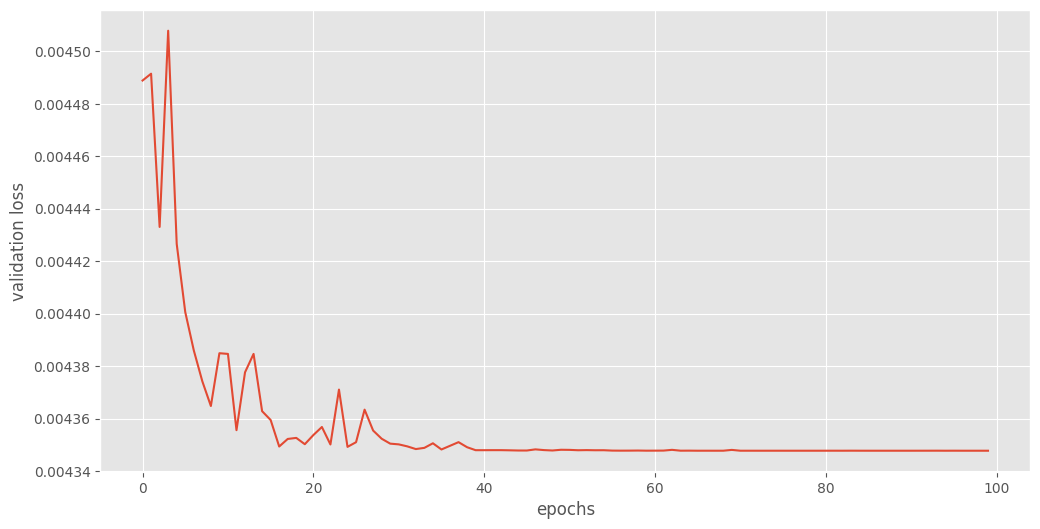

In [194]:
plt.style.use('ggplot')
fig, (ax2) = plt.subplots(1, figsize=(12, 6), sharex=True)
ax2.plot(loss_list)
ax2.set_ylabel("validation loss")
ax2.set_xlabel("epochs")

---